# Purpose of Script

The purpose of this script is to simply get familiar with Google Cloud, the formatting, and general data models.

Resource https://omophub.com/blog/omop-data-model$0  
SNOMED Codes: https://evsexplore.semantics.cancer.gov/evsexplore/hierarchy/snomedct_us/24662006$0

https://www.ohdsi.org/wp-content/uploads/2019/09/OHDSI-Vocabulary-CDM-Tutorial.pdf$0

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

from google.colab.sql import bigquery as bq

Influenza SNOMED CT Codes found through the url above

In [2]:
## google search
# influenza_snomed = ["6142004", , "442438000", "442696006", "772810003", "24662006", "195878008"]

In [3]:
## A, B, C, and "caused by pandemic influenza virus" codes
influenza_snomed_official = [4266367, 24662006, 81524006, 719865001]

In [4]:
influenza_snomed_codes = {'general_flu' : "6142004",
                          'flu_virus' : "725894000",
                          'flu_b' :  "24662006",
                          'flu_a' :"442438000",
                          'seasonal_flu' : "719590007",
                          'pandemic_flu' : "719865001",
                          'flu_c' : "81524006"
                          }

In [5]:
## Tables and columns used backticks

In [6]:
### beter direct in python
query = """
            SELECT *
            FROM `bigquery-public-data.cms_synthetic_patient_data_omop.vocabulary`
            WHERE `vocabulary_id` = 'SNOMED'
            ;"""


df = bq.run(query)
display(df)

,vocabulary_id,vocabulary_name,vocabulary_reference,vocabulary_version,vocabulary_concept_id
0,SNOMED,Systematic Nomenclature of Medicine - Clinical...,http://www.nlm.nih.gov/research/umls/licensedc...,SnomedCT Release 20170401,44819097


In [7]:
# vocabulary_id -> vocabulary_concept_id
# 'SNOMED' -> 44819097

### Concept Preview
Look at flu especially

In [8]:
### beter direct in python than sql blocks
query = """
            SELECT *
            FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
            LIMIT 5
            ;"""

df = bq.run(query)
display(df)

query = """
            SELECT DISTINCT(`domain_id`) AS `unique_concept_domains`
            FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
            LIMIT 100
            ;"""

df = bq.run(query)
display(df)

,concept_id,concept_name,domain_id,vocabulary_id,concept_class_id,standard_concept,concept_code,valid_start_date,valid_end_date,invalid_reason
0,3041910,Deprecated Gastrointestine upper Fluoroscopy W...,Observation,LOINC,Clinical Observation,<NA>,39143-3,1970-01-01,2010-08-27,U
1,45958992,Acetate,Observation,SNOMED,Substance,<NA>,16609611000001107,1970-01-01,2012-10-03,U
2,45974650,Menthol and Eucalyptus inhalation,Drug,SNOMED,Pharma/Biol Product,<NA>,3655511000001106,1970-01-01,2012-10-03,U
3,40664437,"Fludarabine phosphate, oral, 1 mg",Drug,HCPCS,HCPCS,<NA>,C9262,2011-01-09,2014-11-11,D
4,40664572,"Injection, von willebrand factor complex (huma...",Drug,HCPCS,HCPCS,<NA>,C9267,2011-01-09,2014-11-11,D


,unique_concept_domains
0,Procedure
1,Place of Service
2,Type Concept
3,Race
4,Meas Value
5,Meas Value Operator
6,Drug
7,Device
8,Measurement
9,Condition


Relevant concept -> condition, condition/procedure, condition/meas, condiction/device, clinical finding?

In [9]:
### beter direct in python
query = """
            SELECT *
            FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
            WHERE LOWER(`concept_name`) like '%influenza%'
            LIMIT 10
            ;"""

df = bq.run(query)
display(df)

,concept_id,concept_name,domain_id,vocabulary_id,concept_class_id,standard_concept,concept_code,valid_start_date,valid_end_date,invalid_reason
0,2617562,Patient not documented to have received influe...,Observation,HCPCS,HCPCS,<NA>,G8109,1970-01-01,2014-11-11,D
1,2617825,"Influenza vaccine status screened, patient not...",Observation,HCPCS,HCPCS,<NA>,G8425,1970-01-01,2014-11-11,D
2,45322202,"Influenza Virus Vaccine, Inactivated A-Brisban...",Drug,NDC,11-digit NDC,<NA>,19515088607,2009-10-01,2014-03-01,D
3,44915429,FLUZONE INFLUENZA A VIRUS A/CALIFORNIA/7/2009 ...,Drug,NDC,11-digit NDC,<NA>,49281038615,2010-09-01,2014-03-01,D
4,45170618,FLUZONE INFLUENZA A VIRUS A/CALIFORNIA/7/2009 ...,Drug,NDC,11-digit NDC,<NA>,49281038765,2010-09-01,2014-03-01,D
5,45023508,"0.5 ML Influenza A virus vaccine, A-California...",Drug,NDC,11-digit NDC,<NA>,63851061111,2013-01-01,2015-08-01,D
6,44878989,"Influenza Virus Vaccine, Inactivated A-Califor...",Drug,NDC,11-digit NDC,<NA>,19515088707,2010-09-01,2013-07-01,D
7,46233693,FluMist Quadrivalent influenza vaccine live in...,Drug,NDC,11-digit NDC,<NA>,66019030010,2013-07-01,2013-07-01,D
8,42874464,"ALDESLEUKIN/INFLUENZA VIRUS,TRIVALENT SPLIT VA...",Drug,NDFRT,Drug Interaction,<NA>,N0000185179,2012-09-04,2014-11-30,D
9,42874567,"AXITINIB/INFLUENZA VIRUS,LIVE",Drug,NDFRT,Drug Interaction,<NA>,N0000185282,2012-09-04,2014-11-30,D


In [10]:
query = """
            SELECT distinct(`vocabulary_id`)
            FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
            WHERE 1=1
            AND LOWER(`concept_name`) like '%influenza%'
            AND `domain_id` = 'Condition'
            LIMIT 100
            ;"""

df = bq.run(query)

display(df)

,vocabulary_id
0,SNOMED
1,ICD9CM
2,ICD10CM


In [11]:
query = """
            SELECT distinct(`vocabulary_id`)
            FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
            WHERE 1=1
            -- AND LOWER(`concept_name`) like '%influenza%'
            AND `domain_id` = 'Condition'
            LIMIT 100
            ;"""

## the following vocabularies are for 'conditions'
df = bq.run(query)

display(df)

,vocabulary_id
0,HCPCS
1,ICD10CM
2,ICD9CM
3,SNOMED


In [12]:
# -- concept_code is string from website

query = f"""
        SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
        WHERE `concept_code` IN {tuple(influenza_snomed_codes.values())}
        --  AND `domain_id` = 'Condition'
        LIMIT 100
        ;"""

df = bq.run(query)

## funky format - correct to python int
# df['concept_id'] = [int(x) for x in df['concept_id']]

## all "Condition" in domain_id - maybe always - maybe inconsistent
display(df)

,concept_id,concept_name,domain_id,vocabulary_id,concept_class_id,standard_concept,concept_code,valid_start_date,valid_end_date,invalid_reason
0,36714388,Influenza caused by seasonal influenza virus,Condition,SNOMED,Clinical Finding,S,719590007,2017-01-31,2099-12-31,<NA>
1,4304374,"Influenza due to Influenza virus, type C",Condition,SNOMED,Clinical Finding,S,81524006,1970-01-01,2099-12-31,<NA>
2,4266367,Influenza,Condition,SNOMED,Clinical Finding,S,6142004,1970-01-01,2099-12-31,<NA>
3,40483537,Influenza due to Influenza A virus,Condition,SNOMED,Clinical Finding,S,442438000,2009-07-31,2099-12-31,<NA>
4,36714570,Influenza caused by pandemic influenza virus,Condition,SNOMED,Clinical Finding,S,719865001,2017-01-31,2099-12-31,<NA>
5,4080680,"Influenza due to Influenza virus, type B",Condition,SNOMED,Clinical Finding,S,24662006,1970-01-01,2099-12-31,<NA>


In [16]:
query = """
            SELECT *
            FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
            WHERE 1=1
            AND LOWER(`concept_name`) like '%influenza%'
            AND LOWER(`concept_name`) like '%vaccin%'
            AND `invalid_reason` is null
            AND `concept_code` = '86198006' -- snomed
            -- AND `domain_id` = 'Condition'
            LIMIT 100
            ;"""

df = bq.run(query)

print("Flu conditions by substring:")
display(df)

Flu conditions by substring:


,concept_id,concept_name,domain_id,vocabulary_id,concept_class_id,standard_concept,concept_code,valid_start_date,valid_end_date,invalid_reason
0,4313306,Influenza vaccination,Procedure,SNOMED,Procedure,S,86198006,1970-01-01,2099-12-31,<NA>


In [15]:
query = """
            SELECT *
            FROM `bigquery-public-data.cms_synthetic_patient_data_omop.drug_exposure`
            -- WHERE LOWER(`concept_name`) like '%influenza%'
            -- AND LOWER(`concept_name`) like '%vaccin%'
            -- AND `invalid_reason` is null
            -- AND `domain_id` = 'Condition'
            LIMIT 100
            ;"""

df = bq.run(query)

display(df)

,drug_type_concept_id,stop_reason,refills,quantity,days_supply,sig,route_concept_id,lot_number,provider_id,visit_occurrence_id,...,route_source_value,dose_unit_source_value,drug_exposure_id,person_id,drug_concept_id,drug_exposure_start_date,drug_exposure_start_datetime,drug_exposure_end_date,drug_exposure_end_datetime,verbatim_end_date
0,38000175,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,144877,92877462,...,<NA>,<NA>,104905532,1936306,2213440,2008-06-20,<NA>,2008-07-20,<NA>,<NA>
1,38000175,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3052,81313684,...,<NA>,<NA>,91830378,1695132,1154186,2008-06-20,<NA>,2008-07-20,<NA>,<NA>
2,38000175,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,191766,43181666,...,<NA>,<NA>,48777819,900087,2213440,2008-06-20,<NA>,2008-07-20,<NA>,<NA>
3,38000175,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,5091,83690686,...,<NA>,<NA>,94503414,1744738,1301125,2008-06-20,<NA>,2008-07-20,<NA>,<NA>
4,38000175,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,277946,31947806,...,<NA>,<NA>,36089699,665929,1301125,2008-06-20,<NA>,2008-07-20,<NA>,<NA>
5,38000175,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25647,50058729,...,<NA>,<NA>,56554613,1043580,1304850,2008-06-20,<NA>,2008-07-20,<NA>,<NA>
6,38000175,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,168514,39574766,...,<NA>,<NA>,44703983,824748,2213440,2008-06-20,<NA>,2008-07-20,<NA>,<NA>
7,38000175,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,27154,52546568,...,<NA>,<NA>,59387059,1095723,40098312,2008-06-20,<NA>,2008-07-20,<NA>,<NA>
8,38000175,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,240542,43908458,...,<NA>,<NA>,49600294,915365,40098312,2008-06-20,<NA>,2008-07-20,<NA>,<NA>
9,38000175,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,41126,90039520,...,<NA>,<NA>,101682856,1877127,40072348,2008-06-20,<NA>,2008-07-20,<NA>,<NA>


In [ ]:
# df['concept_id_2'] = [int(x) for x in df['concept_id']]

In [ ]:
df.dtypes

In [ ]:
influenza_snomed_concept_ids = dict(zip(df['concept_name'], df['concept_id_2']))
influenza_snomed_concept_ids

How to go from flu -> diagnosis of person?  

1. Flu -> concept table.
2. Condition occurrence -> Diagnosis of Flu to a person.
  - need to filter to actual flu diagnoses and not noise    
3. Person -> person_table


flu ->


In [ ]:
# class_concept_id => Diagnosis

In [ ]:
# query = f"""
#         SELECT *
#         FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
#         WHERE 1 = 1
#         -- AND LOWER(`concept_name`) like '%influenza%'
#         AND lower(`concept_class_id`) like '%diagnosis%'
#         -- AND `concept_code` IN {tuple(influenza_snomed)} -- concept_code is string
#         --  AND `domain_id` = 'Condition'
#         LIMIT 100
#         ;"""

# df = bq.run(query)

# ## all "Condition" in domain_id - maybe always - maybe inconsistent
# display(df)

In [ ]:
query = f"""
        SELECT distinct(`concept_class_id`) as `unique_concepts`
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
        WHERE 1 = 1
        -- AND LOWER(`concept_name`) like '%influenza%'
        -- AND `concept_class_id` = 'Diagnosis'
        -- AND `concept_code` IN {tuple(influenza_snomed_codes.values())} -- concept_code is string
        --  AND `domain_id` = 'Condition'
        LIMIT 100
        ;"""

df = bq.run(query)

## all "Condition" in domain_id - maybe always - maybe inconsistent
display(df)

## Person Preview



In [ ]:
query = """
              SELECT *
FROM `bigquery-public-data.cms_synthetic_patient_data_omop.person`
limit 5
"""

df = bq.run(query)
display(df)

query = """
        SELECT COUNT(DISTINCT(`person_id`)) as `num_total_people`
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.person`
        ;"""

df = bq.run(query)

display(df)

,race_concept_id,ethnicity_concept_id,location_id,provider_id,care_site_id,person_source_value,gender_source_value,gender_source_concept_id,race_source_value,race_source_concept_id,ethnicity_source_value,ethnicity_source_concept_id,person_id,gender_concept_id,year_of_birth,month_of_birth,day_of_birth,birth_datetime
0,8527,38003564,1743,<NA>,<NA>,BF15581F0A520581,1,<NA>,1,<NA>,1,<NA>,1017694,8507,1909,1,1,<NA>
1,8527,38003564,1489,<NA>,<NA>,7F50CE39B134C698,1,<NA>,1,<NA>,1,<NA>,1569978,8507,1910,1,1,<NA>
2,8527,38003564,218,<NA>,<NA>,EC10EF79BF40061F,1,<NA>,1,<NA>,1,<NA>,456313,8507,1912,1,1,<NA>
3,8527,38003564,1778,<NA>,<NA>,94E7BB02907B8B25,1,<NA>,1,<NA>,1,<NA>,649532,8507,1914,1,1,<NA>
4,8527,38003564,1338,<NA>,<NA>,DF6649197A018AB0,1,<NA>,1,<NA>,1,<NA>,2079297,8507,1914,1,1,<NA>


,num_total_people
0,2326856


## Condition Occurrence Preview

CONDITION_OCCURRENCE: This is where you’ll find all patient diagnoses, from chronic illnesses to acute infections. Each row represents a specific condition like 'Type 2 diabetes' or 'acute bronchitis,' tied to a patient and, usually, to the visit when it was first diagnosed.

In [ ]:
query = """
          SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.condition_occurrence`
        limit 5
        """

df = bq.run(query)
display(df)

query = f"""
        SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.condition_occurrence`
        WHERE `condition_concept_id` = 4266367
        limit 5
        """

df = bq.run(query)
display(df)

query = f"""
        SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.condition_occurrence`
        WHERE `condition_type_concept_id` = 4266367
        limit 5
        """

df = bq.run(query)
display(df)


query = f"""
        SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.condition_occurrence`
        WHERE `condition_source_concept_id` = 4266367
        limit 5
        """

df = bq.run(query)
display(df)

### Nobody has flu above by searching that column

## Domain Preview

In [ ]:
query = f"""
        SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.domain`
        WHERE 1 = 1
        LIMIT 100
        ;"""

df = bq.run(query)

## all "Condition" in domain_id - maybe always - maybe inconsistent
display(df)

## Concept Relationships

In [ ]:
query = f"""
        SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept_relationship`
        WHERE 1 = 1
        LIMIT 100
        ;"""

df = bq.run(query)

## all "Condition" in domain_id - maybe always - maybe inconsistent
display(df)

In [ ]:
# dataframe:
# uuid: E019901F-16AA-42AB-9563-A38B7B6EF6FE
# output_variable:
# config_str:

import google.colabsqlviz.explore_dataframe as _vizcell
_vizcell.explore_dataframe(df_or_df_name='', uuid='E019901F-16AA-42AB-9563-A38B7B6EF6FE')

In [ ]:
influenza_snomed_concept_ids.values()

In [ ]:
query = f"""
        WITH concept_ids_from_code AS (
        SELECT `concept_id`
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
        WHERE `concept_code` IN {tuple(influenza_snomed_codes.values())}
        -- LIMIT 100
        ),

        concept_relations as (
        SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept_relationship`
        WHERE 1 = 1
        -- AND `concept_id_1` = 4266367
        AND `concept_id_1` IN
            (
            SELECT c.`concept_id`
            from `concept_ids_from_code` c
            )
        )

        SELECT *
        FROM concept_relations
        ;"""

df = bq.run(query)

## all "Condition" in domain_id - maybe always - maybe inconsistent
display(df)

,concept_id_1,concept_id_2,relationship_id,valid_start_date,valid_end_date,invalid_reason
0,4266367,46273463,Subsumes,2015-07-31,2099-12-31,<NA>
1,4266367,4144103,Mapped from,1970-01-01,2099-12-31,<NA>
2,36714388,36714388,Maps to,2017-01-31,2099-12-31,<NA>
3,4266367,37394476,Subsumes,2016-07-31,2099-12-31,<NA>
4,40483537,4177956,Has causative agent,2016-01-31,2099-12-31,<NA>
5,4080680,4080680,Mapped from,1970-01-01,2099-12-31,<NA>
6,36714570,4266367,Is a,2017-01-31,2099-12-31,<NA>
7,4080680,4266367,Is a,2011-07-31,2099-12-31,<NA>
8,40483537,314979,Subsumes,2011-07-31,2099-12-31,<NA>
9,4266367,44796183,Mapped from,2016-07-31,2099-12-31,<NA>


In [ ]:
query = f"""
        SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept_relationship`
        WHERE 1 = 1
        AND `concept_id_1` = 719865001
        LIMIT 100
        ;"""

df = bq.run(query)

## all "Condition" in domain_id - maybe always - maybe inconsistent
display(df)

## Concept Ancestors

In [ ]:
query = f"""

      WITH concept_ids_from_code AS (
        SELECT `concept_id`
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
        WHERE `concept_code` IN {tuple(influenza_snomed_codes.values())}
        ),


      ancestor_values AS (

        SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept_ancestor`
        WHERE 1 = 1
        -- AND `ancestor_concept_id` = 4266367
        AND `ancestor_concept_id` in
        (select c.`concept_id`
        from `concept_ids_from_code` c)
        )

      select *
      from `ancestor_values`
        ;"""

df = bq.run(query)

## all "Condition" in domain_id - maybe always - maybe inconsistent
display(df)

,ancestor_concept_id,descendant_concept_id,min_levels_of_separation,max_levels_of_separation
0,40483537,40483537,0,0
1,4266367,4080680,1,1
2,4266367,46270122,3,3
3,4266367,4266367,0,0
4,4266367,4112664,2,2
5,4266367,40484544,2,2
6,4266367,312664,1,1
7,4266367,256723,1,1
8,4266367,4248810,1,1
9,4266367,4112662,2,2


In [ ]:
query = f"""

        WITH flu_subtypes AS
        ( SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept_ancestor`
        WHERE 1 = 1
        AND `ancestor_concept_id` IN (
          SELECT `concept_id`
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
        WHERE `concept_code` IN {tuple(influenza_snomed_codes.values())}
        )
        ),

        flu_happened as (
        SELECT *,
        EXTRACT(MONTH from `condition_start_date`) AS condition_start_date_month,
        EXTRACT(YEAR from `condition_start_date`) AS condition_start_date_year,
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.condition_occurrence`
        WHERE `condition_concept_id` IN
                    (
                    SELECT DISTINCT(f.`descendant_concept_id`)
                    FROM flu_subtypes f
                    )
        )

        select *
        FROM flu_happened
        """

df = bq.run(query)
display(df)

,condition_occurrence_id,person_id,condition_concept_id,condition_start_date,condition_start_datetime,condition_end_date,condition_end_datetime,condition_type_concept_id,stop_reason,provider_id,visit_occurrence_id,visit_detail_id,condition_source_value,condition_source_concept_id,condition_status_source_value,condition_status_concept_id,condition_start_date_month
0,218632676,1759466,256723,2008-08-25,<NA>,2008-09-02,<NA>,38000200,<NA>,310186,84405607,<NA>,4870,44830112,<NA>,<NA>,8
1,29485152,237186,256723,2009-11-27,<NA>,2009-11-28,<NA>,38000200,<NA>,28696,11379789,<NA>,4870,44830112,<NA>,<NA>,11
2,236852290,1906329,256723,2009-10-18,<NA>,2009-10-28,<NA>,38000200,<NA>,16510,91437414,<NA>,4870,44830112,<NA>,<NA>,10
3,230532975,1855397,256723,2008-04-24,<NA>,2008-05-01,<NA>,38000200,<NA>,3697,88999229,<NA>,4870,44830112,<NA>,<NA>,4
4,42526795,342133,320752,2008-04-16,<NA>,2008-04-18,<NA>,38000200,<NA>,22704,16414725,<NA>,4878,44832419,<NA>,<NA>,4
5,77649271,624966,256723,2009-10-25,<NA>,2009-10-25,<NA>,38000230,<NA>,268218,29971861,<NA>,4870,44830112,<NA>,<NA>,10
6,39369580,316774,256723,2009-04-20,<NA>,2009-04-20,<NA>,38000230,<NA>,260540,15195835,<NA>,4870,44830112,<NA>,<NA>,4
7,179604320,1445381,256723,2010-05-18,<NA>,2010-05-18,<NA>,38000230,<NA>,280225,69339360,<NA>,4870,44830112,<NA>,<NA>,5
8,156714686,1261190,256723,2008-12-26,<NA>,2008-12-26,<NA>,38000230,<NA>,71285,60502709,<NA>,4870,44830112,<NA>,<NA>,12
9,225928661,1818371,256723,2010-09-13,<NA>,2010-09-18,<NA>,38000230,<NA>,392270,87220921,<NA>,4870,44830112,<NA>,<NA>,9


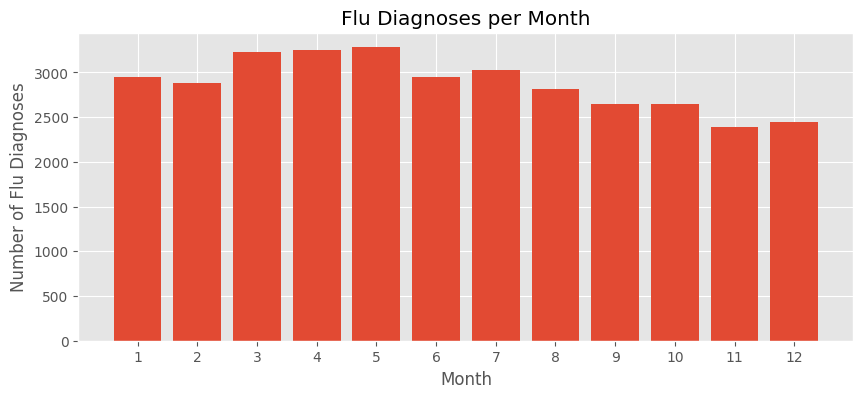

In [ ]:
month_order = df['condition_start_date_month'].value_counts().sort_index().reset_index()

fig, ax = plt.subplots(figsize=(10,4))

plt.bar(month_order['condition_start_date_month'], month_order['count'])
plt.xticks(np.arange(1, 13, 1))
plt.xlabel("Month")
plt.ylabel("Number of Flu Diagnoses")
plt.title("Flu Diagnoses per Month")

plt.show()

In [ ]:
month_order

In [ ]:
query = f"""

        WITH flu_subtypes AS
        ( SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept_ancestor`
        WHERE 1 = 1
        AND `ancestor_concept_id` IN (
          SELECT `concept_id`
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
        WHERE `concept_code` IN {tuple(influenza_snomed_codes.values())}
        )
        ),

        flu_happened as (
        SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.condition_occurrence`
        WHERE `condition_concept_id` IN
                    (
                    SELECT DISTINCT(f.`descendant_concept_id`)
                    FROM flu_subtypes f
                    )
        ),

        people_w_flu as (

        SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.person`
        WHERE `person_id` IN
                    (
                    SELECT DISTINCT(f.`person_id`)
                    FROM flu_happened f
                    )

        ),

        people_w_location as (
        SELECT *
        FROM people_w_flu pf
        JOIN `bigquery-public-data.cms_synthetic_patient_data_omop.location` l
        using(`location_id`)
        )

        select *
        FROM people_w_location
        """

df = bq.run(query)
display(df)

,location_id,race_concept_id,ethnicity_concept_id,provider_id,care_site_id,person_source_value,gender_source_value,gender_source_concept_id,race_source_value,race_source_concept_id,...,month_of_birth,day_of_birth,birth_datetime,address_1,address_2,city,state,zip,county,location_source_value
0,159,8527,38003564,<NA>,<NA>,4C4D604A11673372,1,<NA>,1,<NA>,...,1,1,<NA>,<NA>,<NA>,<NA>,MA,<NA>,22090,22-090
1,57,8527,38003564,<NA>,<NA>,33CA809548288DB9,1,<NA>,1,<NA>,...,1,1,<NA>,<NA>,<NA>,<NA>,IL,<NA>,14141,14-141
2,556,8527,38003564,<NA>,<NA>,A5B25AA172029939,1,<NA>,1,<NA>,...,1,1,<NA>,<NA>,<NA>,<NA>,CA,<NA>,05530,05-530
3,1412,8527,38003564,<NA>,<NA>,C44563405E98E410,1,<NA>,1,<NA>,...,1,1,<NA>,<NA>,<NA>,<NA>,MN,<NA>,24120,24-120
4,116,8527,38003564,<NA>,<NA>,70526A36997B2FCC,1,<NA>,1,<NA>,...,1,1,<NA>,<NA>,<NA>,<NA>,WA,<NA>,50260,50-260
5,341,8527,38003564,<NA>,<NA>,C7AB9E812E8AEA58,1,<NA>,1,<NA>,...,1,1,<NA>,<NA>,<NA>,<NA>,TX,<NA>,45610,45-610
6,18,8527,38003564,<NA>,<NA>,9D4360DEF030E568,1,<NA>,1,<NA>,...,1,1,<NA>,<NA>,<NA>,<NA>,WA,<NA>,50160,50-160
7,2625,8527,38003564,<NA>,<NA>,0883B587E6856E38,1,<NA>,1,<NA>,...,1,1,<NA>,<NA>,<NA>,<NA>,AR,<NA>,04190,04-190
8,1011,8527,38003564,<NA>,<NA>,44661AF02E8E889B,1,<NA>,1,<NA>,...,1,1,<NA>,<NA>,<NA>,<NA>,MO,<NA>,26720,26-720
9,440,8527,38003564,<NA>,<NA>,781D0C6C2E8D6A32,1,<NA>,1,<NA>,...,1,1,<NA>,<NA>,<NA>,<NA>,CA,<NA>,05000,05-000


In [ ]:
display(df['race_concept_id'].value_counts())

display(df['ethnicity_concept_id'].value_counts())

display(df['state'].value_counts().sort_values(ascending=False))

race_concept_id
8527    21220
8516     2487
0        1386
Name: count, dtype: Int64

ethnicity_concept_id
38003564    24564
38003563      529
Name: count, dtype: Int64

state
CA    2056
FL    1782
TX    1695
NY    1551
PA    1058
IL    1056
OH     970
MI     913
NC     833
NJ     772
Name: count, dtype: Int64
...

[52 rows]

In [ ]:
query = f"""

        WITH flu_subtypes AS
        ( SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept_ancestor`
        WHERE 1 = 1
        AND `ancestor_concept_id` IN (
          SELECT `concept_id`
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
        WHERE `concept_code` IN {tuple(influenza_snomed_codes.values())}
        )
        ),

        subtype_concept_details as (
        SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
        WHERE `concept_id` IN
                    (
                    SELECT DISTINCT(f.`descendant_concept_id`)
                    FROM flu_subtypes f
                    )
        )

        select *
        FROM subtype_concept_details
        """

df = bq.run(query)
display(df)

,concept_id,concept_name,domain_id,vocabulary_id,concept_class_id,standard_concept,concept_code,valid_start_date,valid_end_date,invalid_reason
0,36714570,Influenza caused by pandemic influenza virus,Condition,SNOMED,Clinical Finding,S,719865001,2017-01-31,2099-12-31,<NA>
1,46270122,Upper respiratory tract infection due to H1N1 ...,Condition,SNOMED,Clinical Finding,S,142941000119109,2015-07-31,2099-12-31,<NA>
2,46270318,Pneumonia due to influenza,Condition,SNOMED,Clinical Finding,S,16311000119108,2015-07-31,2099-12-31,<NA>
3,37394477,Influenza due to pandemic influenza virus,Condition,SNOMED,Clinical Finding,S,1033071000000105,2016-07-31,2099-12-31,<NA>
4,46270120,Upper respiratory tract infection due to avian...,Condition,SNOMED,Clinical Finding,S,142921000119103,2015-07-31,2099-12-31,<NA>
5,46272714,"Influenza due to influenza virus type A, avian...",Condition,SNOMED,Clinical Finding,S,711128004,2015-07-31,2099-12-31,<NA>
6,46270491,Upper respiratory tract infection due to Influ...,Condition,SNOMED,Clinical Finding,S,328531000119104,2015-07-31,2099-12-31,<NA>
7,4110512,Influenza with pharyngitis,Condition,SNOMED,Clinical Finding,S,195924009,1970-01-01,2099-12-31,<NA>
8,314979,Avian influenza,Condition,SNOMED,Clinical Finding,S,55604004,1970-01-01,2099-12-31,<NA>
9,4183609,Influenzal acute upper respiratory infection,Condition,SNOMED,Clinical Finding,S,43692000,1970-01-01,2099-12-31,<NA>


In [ ]:
query = f"""

        WITH flu_subtypes AS
        ( SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept_ancestor`
        WHERE 1 = 1
        AND `ancestor_concept_id` IN (
          SELECT `concept_id`
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
        WHERE `concept_code` IN {tuple(influenza_snomed_codes.values())}
        )
        ),

        flu_happened as (
        SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.condition_occurrence`
        WHERE `condition_concept_id` IN
                    (
                    SELECT DISTINCT(f.`descendant_concept_id`)
                    FROM flu_subtypes f
                    )
        )

        select COUNT(DISTINCT(`person_id`)) as `people_w_flu`
        FROM flu_happened
        """

df = bq.run(query)
display(df)

,people_w_flu
0,25093


In [ ]:
query = f"""

        WITH flu_subtypes AS
        ( SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept_ancestor`
        WHERE 1 = 1
        AND `ancestor_concept_id` IN (
          SELECT `concept_id`
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
        WHERE `concept_code` IN {tuple(influenza_snomed_codes.values())}
        )
        ),

        flu_happened as (
        SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.condition_occurrence`
        WHERE `condition_concept_id` IN
                    (
                    SELECT DISTINCT(f.`descendant_concept_id`)
                    FROM flu_subtypes f
                    )
        )

        select `person_id`, COUNT(`person_id`) as `num_times_w_flu`
        FROM flu_happened
        GROUP BY `person_id`
        ORDER BY num_times_w_flu DESC
        """

df = bq.run(query)
display(df)

,person_id,num_times_w_flu
0,690590,14
1,1146121,14
2,1161688,14
3,1816418,14
4,959764,13
5,905288,13
6,300132,13
7,1449287,13
8,239909,13
9,735343,13


In [ ]:
df['num_times_w_flu'].value_counts().sort_index(ascending=False)

num_times_w_flu
14      4
13      9
12      8
11      5
10     18
9      14
8      35
7      75
6     140
5     224
Name: count, dtype: Int64
...

[14 rows]

In [ ]:
query = """
        SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.condition_occurrence`
        WHERE `person_id` = 690590
        ORDER BY `condition_start_date`
        """

df = bq.run(query)
display(df)


query = """
        WITH flu_often_person AS
        (SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.condition_occurrence`
        WHERE `person_id` = 690590
        ),

        date_ranges as (
        SELECT min(condition_start_date) as `first_time_sick`,
              max(condition_end_date) as `last_time_sick`
              FROM flu_often_person f

        )

        SELECT *
        FROM date_ranges
        """

df = bq.run(query)
display(df)

,condition_occurrence_id,person_id,condition_concept_id,condition_start_date,condition_start_datetime,condition_end_date,condition_end_datetime,condition_type_concept_id,stop_reason,provider_id,visit_occurrence_id,visit_detail_id,condition_source_value,condition_source_concept_id,condition_status_source_value,condition_status_concept_id
0,85830940,690590,433736,2008-01-21,<NA>,2008-01-26,<NA>,38000230,<NA>,990,33129164,<NA>,27800,44833387,<NA>,<NA>
1,85830939,690590,73301,2008-01-21,<NA>,2008-01-26,<NA>,38000230,<NA>,990,33129164,<NA>,72705,44836206,<NA>,<NA>
2,85831200,690590,254061,2008-02-01,<NA>,2008-02-01,<NA>,38000230,<NA>,1023,33129252,<NA>,5118,44829017,<NA>,<NA>
3,85830926,690590,196151,2008-02-02,<NA>,2008-02-02,<NA>,38000230,<NA>,2310,33129154,<NA>,56489,44823181,<NA>,<NA>
4,85831252,690590,26441,2008-02-04,<NA>,2008-02-04,<NA>,38000230,<NA>,128948,33129277,<NA>,53021,44833629,<NA>,<NA>
5,85831253,690590,435796,2008-02-04,<NA>,2008-02-04,<NA>,38000230,<NA>,128948,33129277,<NA>,27651,44828809,<NA>,<NA>
6,85831251,690590,252663,2008-02-04,<NA>,2008-02-04,<NA>,38000230,<NA>,128948,33129277,<NA>,5070,44820894,<NA>,<NA>
7,85831255,690590,252663,2008-02-04,<NA>,2008-02-04,<NA>,38000230,<NA>,128948,33129277,<NA>,5070,44820894,<NA>,<NA>
8,85831254,690590,313878,2008-02-04,<NA>,2008-02-04,<NA>,38000230,<NA>,128948,33129277,<NA>,78609,44824626,<NA>,<NA>
9,85830986,690590,437834,2008-02-11,<NA>,2008-02-11,<NA>,38000230,<NA>,1011,33129182,<NA>,28319,44835767,<NA>,<NA>


,first_time_sick,last_time_sick
0,2008-01-21,2010-12-22


In [ ]:
444406

bq.run("""SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept`
        WHERE `concept_id` = 444406;
        """)

,concept_id,concept_name,domain_id,vocabulary_id,concept_class_id,standard_concept,concept_code,valid_start_date,valid_end_date,invalid_reason
0,444406,Acute subendocardial infarction,Condition,SNOMED,Clinical Finding,S,70422006,1970-01-01,2099-12-31,<NA>


In [ ]:
influenza_snomed_codes

{'general_flu': '6142004',
 'flu_virus': '725894000',
 'flu_b': '24662006',
 'flu_a': '442438000',
 'seasonal_flu': '719590007',
 'pandemic_flu': '719865001',
 'flu_c': '81524006'}

In [ ]:
query = """
        WITH flu_often_person AS
        (SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.condition_occurrence`
        WHERE `person_id` = 1113171
        )

        select *
        from flu_often_person
        order by condition_concept_id
        """

bq.run(query) ## lots of different providers

,condition_occurrence_id,person_id,condition_concept_id,condition_start_date,condition_start_datetime,condition_end_date,condition_end_datetime,condition_type_concept_id,stop_reason,provider_id,visit_occurrence_id,visit_detail_id,condition_source_value,condition_source_concept_id,condition_status_source_value,condition_status_concept_id
0,138272197,1113171,0,2008-03-21,<NA>,2008-03-22,<NA>,38000230,<NA>,48810,53383667,<NA>,5859,44836035,<NA>,<NA>
1,138272430,1113171,24609,2009-05-30,<NA>,2009-05-31,<NA>,38000230,<NA>,48806,53383752,<NA>,2512,44831048,<NA>,<NA>
2,138272429,1113171,24609,2009-05-30,<NA>,2009-05-31,<NA>,38000230,<NA>,48806,53383752,<NA>,2512,44831048,<NA>,<NA>
3,138272424,1113171,26727,2009-03-10,<NA>,2009-03-10,<NA>,38000230,<NA>,48816,53383751,<NA>,5780,44819811,<NA>,<NA>
4,138272426,1113171,27674,2009-03-10,<NA>,2009-03-10,<NA>,38000230,<NA>,48816,53383751,<NA>,78701,44828157,<NA>,<NA>
5,138272375,1113171,27674,2009-03-23,<NA>,2009-03-23,<NA>,38000230,<NA>,48826,53383738,<NA>,78701,44828157,<NA>,<NA>
6,138272402,1113171,30753,2009-11-04,<NA>,2009-11-04,<NA>,38000230,<NA>,48838,53383746,<NA>,53010,44825499,<NA>,<NA>
7,138272487,1113171,30978,2009-03-04,<NA>,2009-03-05,<NA>,38000230,<NA>,223828,53383773,<NA>,28249,44820698,<NA>,<NA>
8,138272323,1113171,31317,2009-08-16,<NA>,2009-08-16,<NA>,38000230,<NA>,5932,53383722,<NA>,78720,44828158,<NA>,<NA>
9,138272484,1113171,31317,2008-03-13,<NA>,2008-03-14,<NA>,38000230,<NA>,48806,53383772,<NA>,78720,44828158,<NA>,<NA>


In [ ]:
## if diagnoses with two flus on the same day - deduplicate

In [ ]:
query  = """SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.death`
        LIMIT 100"""

df = bq.run(query)

display(df)


query  = """SELECT COUNT(DISTINCT(`person_id`)) as `num_deaths`
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.death`
        LIMIT 100"""

df = bq.run(query)

display(df)


## literally every record has a null cause_concept_id
query  = """SELECT COUNT(DISTINCT(`person_id`)) as `num_deaths`
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.death`
        WHERE `cause_concept_id` is not null
        LIMIT 100"""

df = bq.run(query)

display(df)

In [ ]:
query = f"""

        WITH flu_subtypes AS
        ( SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.concept_ancestor`
        WHERE 1 = 1
        AND `ancestor_concept_id` = 4266367
        ),

        death_from_flu as (
        SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.death`
        WHERE `cause_concept_id` IN
                    (
                    SELECT DISTINCT(f.`descendant_concept_id`)
                    FROM flu_subtypes f
                    )
        OR `cause_concept_id` = 4266367
        )

        select *
        FROM death_from_flu
        """

df = bq.run(query)
display(df)

In [ ]:
query = """
        SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.person`
        WHERE `person_id` = 690590
        """

df = bq.run(query)
display(df) ## year of birth 1975 ~ 51 years old

In [ ]:
query = """
        SELECT *
        FROM `bigquery-public-data.cms_synthetic_patient_data_omop.location`
        WHERE `location_id` = 23
        """
df = bq.run(query)
display(df) # Illinois

## Miscellanous

In [ ]:
# bq.run("""SELECT
#     m.person_id,
#     m.measurement_date,
#     m.value_as_number
# FROM
#     `bigquery-public-data.cms_synthetic_patient_data_omop.measurement` m
# JOIN
#     `bigquery-public-data.cms_synthetic_patient_data_omop.concept` c

#     ON m.measurement_concept_id = c.concept_id
# WHERE
#     c.concept_name = 'Systolic blood pressure'
#     AND m.value_as_number > 140
#     AND m.measurement_date >= '2023-01-01';""")


# ## measurement table doesn't exist in the US?